# Лабораторная работа №2. Вариант 12

В этой лабораторной работе ищется минимум функции двух переменных двумя способами:

1. методом перебора по сетке;
2. методом Ньютона.

Затем сравнивается качество результата и время работы методов.

In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np

## Постановка задачи

Дана функция

$$
f(x_1,x_2)=x_1+2x_2+4\sqrt{1+x_1^2+x_2^2}-4.
$$

Область поиска:

$$
[x_1',x_1'']\times[x_2',x_2'']=[-2,2]\times[-3,1].
$$

Точность:

$$
\varepsilon=0.01.
$$

Нужно найти точку минимума $(x_1^*,x_2^*)$ и минимальное значение $f^*$.

In [2]:
def f(x1, x2):
    return x1 + 2 * x2 + 4 * np.sqrt(1 + x1**2 + x2**2) - 4

a1, b1 = -2, 2
a2, b2 = -3, 1
eps = 0.01

## Аналитическая проверка

Пусть

$$
s=\sqrt{1+x_1^2+x_2^2}.
$$

Тогда первые производные:

$$
\frac{\partial f}{\partial x_1}=1+\frac{4x_1}{s},
\qquad
\frac{\partial f}{\partial x_2}=2+\frac{4x_2}{s}.
$$

В точке минимума градиент равен нулю:

$$
1+\frac{4x_1}{s}=0,
\qquad
2+\frac{4x_2}{s}=0.
$$

Отсюда:

$$
x_1=-\frac{s}{4},
\qquad
x_2=-\frac{s}{2}.
$$

Подставляем в $s^2=1+x_1^2+x_2^2$:

$$
s^2=1+\frac{s^2}{16}+\frac{s^2}{4}=1+\frac{5s^2}{16}.
$$

$$
\frac{11s^2}{16}=1,
\qquad
s=\frac4{\sqrt{11}}.
$$

И точный минимум:

$$
x_1^*=-\frac1{\sqrt{11}}\approx-0.3015,
\qquad
x_2^*=-\frac2{\sqrt{11}}\approx-0.6030.
$$

$$
f^*=\sqrt{11}-4\approx-0.6834.
$$

Это нужно как проверка численных методов.

In [3]:
x1_exact = -1 / np.sqrt(11)
x2_exact = -2 / np.sqrt(11)
f_exact = f(x1_exact, x2_exact)
print(f"Точная точка: ({x1_exact:.6f}, {x2_exact:.6f})")
print(f"Точное значение: {f_exact:.6f}")

Точная точка: (-0.301511, -0.603023)
Точное значение: -0.683375


## Метод перебора

Метод перебора строит равномерную сетку с шагом $h=\varepsilon$ и считает функцию во всех узлах.

Плюс метода: он очень простой и не требует производных.

Минус метода: он медленный, потому что количество вычислений быстро растёт при уменьшении шага.

In [4]:
def enumeration(func, x1_bounds, x2_bounds, eps):
    x1_values = np.arange(x1_bounds[0], x1_bounds[1] + eps / 2, eps)
    x2_values = np.arange(x2_bounds[0], x2_bounds[1] + eps / 2, eps)

    best_point = None
    best_value = np.inf
    count = 0
    start = time.perf_counter()

    for x1 in x1_values:
        for x2 in x2_values:
            value = func(x1, x2)
            count += 1
            if value < best_value:
                best_value = value
                best_point = (x1, x2)

    elapsed = time.perf_counter() - start
    return best_point, best_value, count, elapsed

enum_point, enum_value, enum_count, enum_time = enumeration(f, (a1, b1), (a2, b2), eps)
print(f"Точка перебором: ({enum_point[0]:.4f}, {enum_point[1]:.4f})")
print(f"Значение функции: {enum_value:.6f}")
print(f"Количество вычислений: {enum_count}")
print(f"Время: {enum_time:.6f} c")

Точка перебором: (-0.3000, -0.6000)
Значение функции: -0.683362
Количество вычислений: 160801
Время: 0.541339 c


## Метод Ньютона

Метод Ньютона использует градиент и матрицу Гессе. Для функции двух переменных итерация записывается так:

$$
X_{k+1}=X_k-H^{-1}(X_k)\nabla f(X_k).
$$

Градиент:

$$
\nabla f=\left(1+\frac{4x_1}{s},\;2+\frac{4x_2}{s}\right).
$$

Матрица Гессе:

$$
H=\begin{pmatrix}
\frac{4(1+x_2^2)}{s^3} & -\frac{4x_1x_2}{s^3}\\
-\frac{4x_1x_2}{s^3} & \frac{4(1+x_1^2)}{s^3}
\end{pmatrix}.
$$

Начальную точку берём $(0,0)$, она лежит внутри допустимой области.

In [5]:
def grad_f(x1, x2):
    s = np.sqrt(1 + x1**2 + x2**2)
    return np.array([1 + 4 * x1 / s, 2 + 4 * x2 / s])

def hessian_f(x1, x2):
    s = np.sqrt(1 + x1**2 + x2**2)
    s3 = s**3
    return np.array([
        [4 * (1 + x2**2) / s3, -4 * x1 * x2 / s3],
        [-4 * x1 * x2 / s3, 4 * (1 + x1**2) / s3],
    ])

def newton_min(func, grad, hessian, x0, eps, max_iter=100):
    x = np.array(x0, dtype=float)
    history = []
    start = time.perf_counter()

    for k in range(1, max_iter + 1):
        g = grad(x[0], x[1])
        H = hessian(x[0], x[1])
        step = np.linalg.solve(H, g)
        x_next = x - step

        delta_x = np.linalg.norm(x_next - x)
        delta_f = abs(func(x_next[0], x_next[1]) - func(x[0], x[1]))
        history.append((k, x.copy(), func(x[0], x[1]), delta_x, delta_f))

        x = x_next
        if delta_x <= eps:
            break

    elapsed = time.perf_counter() - start
    return x, func(x[0], x[1]), k, elapsed, history

newton_point, newton_value, newton_iterations, newton_time, newton_history = newton_min(
    f, grad_f, hessian_f, (0, 0), eps
)

print(f"Точка Ньютона: ({newton_point[0]:.6f}, {newton_point[1]:.6f})")
print(f"Значение функции: {newton_value:.6f}")
print(f"Итераций: {newton_iterations}")
print(f"Время: {newton_time:.6f} c")

Точка Ньютона: (-0.301490, -0.602980)
Значение функции: -0.683375
Итераций: 3
Время: 0.002403 c


In [6]:
for k, x, value, delta_x, delta_f in newton_history:
    print(f"{k}: x=({x[0]:.6f}, {x[1]:.6f}), f={value:.9f}, |dx|={delta_x:.9f}, |df|={delta_f:.9f}")

1: x=(0.000000, 0.000000), f=0.000000000, |dx|=0.559016994, |df|=0.667424305
2: x=(-0.250000, -0.500000), f=-0.667424305, |dx|=0.106860375, |df|=0.015871632
3: x=(-0.297789, -0.595579), f=-0.683295937, |dx|=0.008274671, |df|=0.000079270


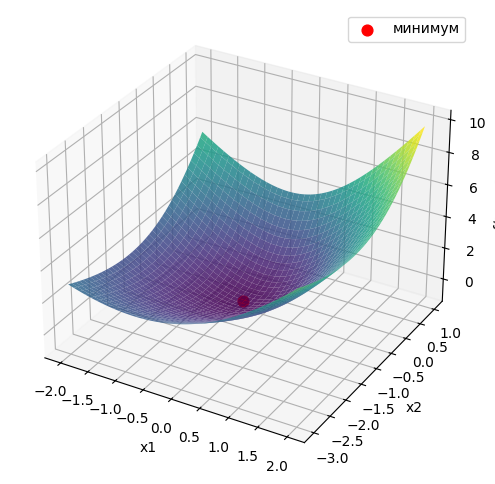

In [7]:
x1_grid = np.linspace(a1, b1, 120)
x2_grid = np.linspace(a2, b2, 120)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = f(X1, X2)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(X1, X2, Z, cmap="viridis", alpha=0.85)
ax.scatter([newton_point[0]], [newton_point[1]], [newton_value], color="red", s=60, label="минимум")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1, x2)")
ax.legend()
plt.show()

## Итог по лабораторной 2

Метод перебора:

$$
(x_1^*,x_2^*)\approx(-0.3000,-0.6000),
\qquad
f^*\approx-0.68336.
$$

Метод Ньютона:

$$
(x_1^*,x_2^*)\approx(-0.3015,-0.6030),
\qquad
f^*\approx-0.68338.
$$

Точная проверка:

$$
(x_1^*,x_2^*)=\left(-\frac1{\sqrt{11}},-\frac2{\sqrt{11}}\right),
\qquad
f^*=\sqrt{11}-4.
$$

